
# Python Inference Tutorial - Single Model

This tutorial describes how to run an inference process using `InferPipeline` API (sync API), which is an alternative to the recommended Async API


**Requirements:**

* Run the notebook inside the Python virtual environment: ```source hailo_virtualenv/bin/activate```

When inside the ```virtualenv```, use the command ``hailo tutorial`` to open a Jupyter server that contains the tutorials.

In [1]:
!pwd

/home/trap-fish/uav-human-detection/hailo-ai/notebooks


In [2]:
import numpy as np
from multiprocessing import Process
from hailo_platform import (HEF, VDevice, HailoStreamInterface, InferVStreams, ConfigureParams,
    InputVStreamParams, OutputVStreamParams, InputVStreams, OutputVStreams, FormatType)

# The target can be used as a context manager ("with" statement) to ensure it's released on time.
# Here it's avoided for the sake of simplicity
target = VDevice()

# Loading compiled HEFs to device:
# model_name = 'yolo11n'
# hef_path = '../hefs/{}.hef'.format(model_name) 
hef_path = '/home/trap-fish/uav-human-detection/models/yolo11n_visdrone.hef'
hef = HEF(hef_path)
    
# Configure network groups
configure_params = ConfigureParams.create_from_hef(hef=hef, interface=HailoStreamInterface.PCIe)
network_groups = target.configure(hef, configure_params)
network_group = network_groups[0]
network_group_params = network_group.create_params()

# Create input and output virtual streams params
input_vstreams_params = InputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)
output_vstreams_params = OutputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)

# Define dataset params
input_vstream_info = hef.get_input_vstream_infos()[0]
output_vstream_info = hef.get_output_vstream_infos()[0]
image_height, image_width, channels = input_vstream_info.shape
num_of_images = 10
low, high = 2, 20

# Generate random dataset
dataset = np.random.randint(low, high, (num_of_images, image_height, image_width, channels)).astype(np.float32)

#### Running hardware inference
Infer the model and then display the output shape:

In [3]:
# Infer 
with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
    input_data = {input_vstream_info.name: dataset}
    with network_group.activate(network_group_params):
        infer_results = infer_pipeline.infer(input_data)
        print(f"Stream output shape is {infer_results[output_vstream_info.name][0][:]}")

infer_results

Stream output shape is [array([], shape=(0, 5), dtype=float64), array([], shape=(0, 5), dtype=float64)]


{'yolo11n_visdrone/yolov8_nms_postprocess': [[array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)]]}

## Streaming inference

This section shows how to run streaming inference using multiple processes in Python.

Note: This flow is not supported on Windows.

We will not use infer. Instead we will use a send and receive model.
The send function and the receive function will run in different processes.

Define the send and receive functions:

In [4]:
def send(configured_network, num_frames):
    configured_network.wait_for_activation(1000)
    vstreams_params = InputVStreamParams.make(configured_network)
    with InputVStreams(configured_network, vstreams_params) as vstreams:
        vstream_to_buffer = {vstream: np.ndarray([1] + list(vstream.shape), dtype=vstream.dtype) for vstream in vstreams}
        for _ in range(num_frames):
            for vstream, buff in vstream_to_buffer.items():
                vstream.send(buff)

def recv(configured_network, vstreams_params, num_frames):
    configured_network.wait_for_activation(1000)
    with OutputVStreams(configured_network, vstreams_params) as vstreams:
        for _ in range(num_frames):
            for vstream in vstreams:
                data = vstream.recv()

def recv_all(configured_network, num_frames):
    vstreams_params_groups = OutputVStreamParams.make_groups(configured_network)
    recv_procs = []
    for vstreams_params in vstreams_params_groups:
        proc = Process(target=recv, args=(configured_network, vstreams_params, num_frames))
        proc.start()
        recv_procs.append(proc)
    for proc in recv_procs:
        proc.join()

Define the amount of frames to stream, define the processes, create the target and run processes:


In [5]:
# Define the amount of frames to stream
num_of_frames = 1000
model_name = "yolo11n_visdrone"

send_process = Process(target=send, args=(network_group, num_of_frames))
recv_process = Process(target=recv_all, args=(network_group, num_of_frames))
recv_process.start()
send_process.start()
print('Starting streaming (hef=\'{}\', num_of_frames={})'.format(model_name, num_of_frames))
with network_group.activate(network_group_params):
    send_process.join()
    recv_process.join()
print('Done')

target.release()

Starting streaming (hef='yolo11n_visdrone', num_of_frames=1000)
Done


## CJM's Tutorial on Hailo8
Seems to mostly just be the above code with minor adjustments

In [5]:
target.release()

In [6]:


# OpenCV for computer vision tasks
import cv2

# NumPy for numerical operations
import numpy as np

# PIL (Python Imaging Library) for image processing
from PIL import Image, ImageDraw, ImageFont

# Import Hailo Runtime dependencies
from hailo_platform import (
    HEF,
    ConfigureParams,
    FormatType,
    HailoSchedulingAlgorithm,
    HailoStreamInterface,
    InferVStreams,
    InputVStreamParams,
    OutputVStreamParams,
    VDevice
)

# Import Picamera2
# from picamera2 import Picamera2, Preview

In [7]:

# Load the compiled HEF to Hailo device
hef_path = '/home/trap-fish/uav-human-detection/models/yolo11n_visdrone.hef'
hef = HEF(str(hef_path))

# Set VDevice (Virtual Device) params to disable the HailoRT service feature
params = VDevice.create_params()
params.scheduling_algorithm = HailoSchedulingAlgorithm.NONE

# Create a Hailo virtual device with the specified parameters
target = VDevice(params=params)

# Get the "network groups" (connectivity groups, aka. "different networks") information from the .hef
# Configure the device with the HEF and PCIe interface
configure_params = ConfigureParams.create_from_hef(hef=hef, interface=HailoStreamInterface.PCIe)
network_groups = target.configure(hef, configure_params)

# Select the first network group (there's only one in this case)
network_group = network_groups[0]
network_group_params = network_group.create_params()

# Create input and output virtual streams params
# These specify the format of the input and output data (in this case, 32-bit float)
input_vstreams_params = InputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)
output_vstreams_params = OutputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)

# Get information about the input and output virtual streams
input_vstream_info = hef.get_input_vstream_infos()[0]
output_vstream_info = hef.get_output_vstream_infos()[0]

In [8]:
import torchvision as tv

def preproc(image, output_height=640, output_width=640):
    preprocess = tv.transforms.Compose([
        tv.transforms.Resize((output_height, output_width)),
    ])
    
    data = np.array(preprocess(image))
    
    return data

In [9]:

sample_frame_path = "/home/trap-fish/uav-human-detection/hailo-ai/exported_from_docker/val/images/0000001_03999_d_0000007.jpg"
# Capture a frame
frame = Image.open(sample_frame_path)

input_img_np = preproc(frame)

# Resize and pad the sample image to the desired input size, retrieving transformation data.
#input_img_np, transform_data = resize_and_pad(frame, input_vstream_info.shape[::-1][1:], True)

# Convert the input image to NumPy format for the model
input_tensor_np = np.array(input_img_np, dtype=np.float32)[None]
input_tensor_np = np.ascontiguousarray(input_tensor_np)

# Run inference
input_data = {input_vstream_info.name: input_tensor_np}
with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
    with network_group.activate(network_group_params):
        infer_results = infer_pipeline.infer(input_data)

# Transpose and extract the first element of the quantized results
outputs = infer_results[output_vstream_info.name]#.transpose(0, 1, 3, 2)[0]


In [10]:
def run_inference(vstream_params, input_data):
    network_group, input_vstreams_params, output_vstreams_params = vstream_params
    #input_data = {input_vstream_info.name: input_tensor}
    with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
        with network_group.activate(network_group_params):
            infer_results = infer_pipeline.infer(input_data)
    return infer_results

In [11]:
import json
import os
import time
rootdir = '/home/trap-fish/uav-human-detection/hailo-ai/'
annotations_file = os.path.join(rootdir, 'shared_with_docker/visdrone/annotations_VisDroneHumans_val.json')
images_path = os.path.join(rootdir, 'shared_with_docker/visdrone/VisDrone2019-DET-val/images')

with open(annotations_file, 'r') as f:
    val_gt = json.load(f)
    f.close()
    
images = val_gt['images']
image_list = [(x['file_name'],x['id']) for x in images] 

print(f"frame count: {len(image_list)}")

frame count: 532


In [12]:
dataset_sz = len(image_list)
val_dataset = np.zeros((dataset_sz, 640, 640, 3))
for idx, imagename_id in enumerate(image_list):
    imgname, imgid = imagename_id
    image_file = os.path.join(images_path, imgname)
    img = Image.open(image_file).convert('RGB')
    img_preproc = preproc(img)
    val_dataset[idx, :, :, :] = img_preproc

In [20]:
# create an np array for the validation dataset
vstream_config = (network_group, input_vstreams_params, output_vstreams_params)
outs = []
start_time = time.perf_counter()
for idx, imagename_id in enumerate(image_list):
    img_arr = val_dataset[idx, :, :, :]
    
    # # Convert the input image to NumPy format for the model
    input_tensor_np = np.array(img_arr, dtype=np.float32)[None]
    input_tensor_np = np.ascontiguousarray(input_tensor_np)
    
    input_data = {input_vstream_info.name: input_tensor_np}

    outs.append(run_inference(vstream_config, input_data))

# Calculate and display FPS
end_time = time.perf_counter()
processing_time = end_time - start_time
fps = 1 / processing_time


TypeError: run_inference() missing 1 required positional argument: 'input_data'

In [14]:
class0preds = []
class1preds = []
for idx, el in enumerate(outs):
    class0preds.append(el.get('yolo11n_visdrone/yolov8_nms_postprocess')[0][0])
    class1preds.append(el.get('yolo11n_visdrone/yolov8_nms_postprocess')[0][1])


In [21]:
print(f"Inference time {processing_time}\nFPS: {len(image_list) * fps}")

Inference time 9.847569055999884
FPS: 54.02348508293682


In [16]:
def run_inference(runner, sdk_type, input_data ):
    if sdk_type == 'quantized':
        with runner.infer_context(InferenceContext.SDK_QUANTIZED) as ctx:
            output = runner.infer(ctx, input_data)
    else:
        with runner.infer_context(InferenceContext.SDK_FP_OPTIMIZED) as ctx:
            output = runner.infer(ctx, input_data)
    return output  

def remove_zero_padding(output, imgid):
    # remove zero-padding and transpose detections into single array
    combined = np.empty((7, 0)) # 1 classid, xywh, score
    for i in range(output.shape[1]):
        valid_mask = np.any(output[0,i,:,:] != 0, axis=(0))  # Check if any non-zero values exist in each column
        last_valid_indices = np.argmax(~valid_mask, axis=0) # First occurrence of zero padding

        dets = output[0, i, :, :last_valid_indices]
        class_col = np.full_like(dets[0,None], i) # add the classID into the array
        imgid_col = np.full_like(dets[0,None], imgid)
        dets = np.vstack((dets, class_col, imgid_col))
        combined = np.concatenate((combined, dets), axis=1)

    dets = combined.T
    return dets


def swap_columns(detections):
    swapped = detections.copy()
    swapped[:, [0, 1,2,3]] = swapped[:, [1, 0, 3, 2]]
    return swapped


def ltxy2xywh(xywh):
    coco_format = np.array(xywh)
    coco_format[:,0] = xywh[:,0] # x
    coco_format[:,1] = xywh[:,1] # y
    coco_format[:,2] = xywh[:,2] - xywh[:,0] # x2 - x1
    coco_format[:,3] = xywh[:,3] - xywh[:,1] # y2 - y1

    return coco_format

def rescale_bbox(detections, w, h):
    w_arr = np.full_like(detections[:,0], w)
    h_arr = np.full_like(detections[:,0], h)
    scaled = np.zeros_like(detections)
    
    scaled[:,0] = detections[:,0] * w_arr
    scaled[:,1] = detections[:,1] * h_arr
    scaled[:,2] = detections[:,2] * w_arr
    scaled[:,3] = detections[:,3] * h_arr
    
    scaled[:, 4:] = detections[:, 4:]
    
    return scaled

def add_metadata_to_dict(data, data_dict):
    idx, imgid, lb_scale, lb_pad_top, lb_pad_left = data
    metadata = {
                "image_id" : imgid,
                "lbox_scale": lb_scale,
                "lbox_pad_top": lb_pad_top, 
                "lbox_pad_left": lb_pad_left
    }


    data_dict[idx]["rescale_data"] = metadata
    


def get_image_metadata(images_dict, img_id):
    for img in images_dict:
        if img['id'] == img_id:
            orig_w, orig_h = img['width'], img['height']
            name = img["file_name"]
            lb_scale = img["rescale_data"]["lbox_scale"]
            lb_pad_top = img["rescale_data"]["lbox_pad_top"]
            lb_pad_left = img["rescale_data"]["lbox_pad_left"]

    return orig_w, orig_h, name, lb_scale, lb_pad_top, lb_pad_left

def batch_detections_to_json(detections):
    class_remap = {0: 1, 1: 2}
    res = []
    annId = 1
    for el in detections:
        x,y,w,h,conf,classid,imgid = el
        imgid = int(imgid)
        res.append({"image_id": imgid, "category_id": class_remap[classid], "bbox": [x,y,w,h], "score": conf, "id": annId, "segmentation": []}) 
        annId +=1
    return res

def stack_image_detections(image_detections, image_id):
    stacked = np.empty((0,7))
    for idx, dets in enumerate(image_detections):
        axis_sz = dets.shape[0]
        dets_with_cls = np.full((axis_sz, 7), idx, dtype="float32")
        dets_with_cls[:, :-2] = dets
        dets_with_cls[:, -1] = image_id
        stacked = np.vstack((stacked, dets_with_cls))
    return stacked

In [17]:
all_image_dets = np.empty((0,7))
for idx, item in enumerate(outs):
    detections = item["yolo11n_visdrone/yolov8_nms_postprocess"]
    single_img_det = stack_image_detections(detections[0], idx+1)
    all_image_dets = np.vstack((all_image_dets, single_img_det))
    
xyxy_dets = swap_columns(all_image_dets)
dets_scaled = rescale_bbox(xyxy_dets, 1920, 1080)
xywh = ltxy2xywh(dets_scaled)
anns_json = batch_detections_to_json(xywh)


In [18]:
with open("detections.json", "w") as f:
    json.dump(anns_json, f)

In [19]:
target.release()

In [29]:
with open("detections.json", "r") as f:
    annotations = json.load(f)

annotations[0:3]

[{'image_id': 1,
  'category_id': 1,
  'bbox': [1207.7593231201172,
   362.1629762649536,
   22.529983520507812,
   36.40345573425293],
  'score': 0.5986363887786865,
  'id': 1,
  'segmentation': []},
 {'image_id': 1,
  'category_id': 1,
  'bbox': [1056.7760467529297,
   180.25413393974304,
   16.437606811523438,
   27.218729853630066],
  'score': 0.5669703483581543,
  'id': 2,
  'segmentation': []},
 {'image_id': 1,
  'category_id': 1,
  'bbox': [1060.52490234375,
   230.54495751857758,
   17.732620239257812,
   31.85434341430664],
  'score': 0.5323989987373352,
  'id': 3,
  'segmentation': []}]

In [30]:
def rescale_bboxes(annotations, image_info):
    # Create a mapping of image_id to its correct dimensions
    image_dims = {img['id']: (img['width'], img['height']) for img in image_info}
    
    # Original incorrect dimensions
    incorrect_w, incorrect_h = 1920, 1080
    
    for ann in annotations:
        img_id = ann['image_id']
        if img_id in image_dims:
            correct_w, correct_h = image_dims[img_id]
            
            # Scale bbox from incorrect to correct dimensions
            x, y, w, h = ann['bbox']
            x = (x / incorrect_w) * correct_w
            y = (y / incorrect_h) * correct_h
            w = (w / incorrect_w) * correct_w
            h = (h / incorrect_h) * correct_h
            
            ann['bbox'] = [x, y, w, h]
    
    return annotations
corrected = rescale_bboxes(annotations, images)
with open("detections_correct.json", "w") as f:
    json.dump(corrected, f)


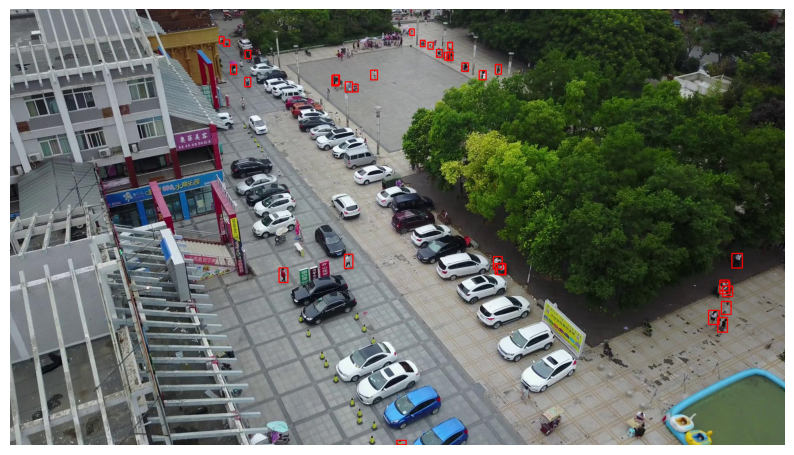

In [31]:
import cv2
import matplotlib.pyplot as plt
def plot_annotations(root_path, annotations, image_id, categories):
    for image in images:
        if image["id"] == image_id:
            filename = image["file_name"]
    image_path = os.path.join(root_path, filename)
    
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Filter annotations for the specific image_id
    image_annotations = [ann for ann in annotations if ann['image_id'] == image_id]
    
    # Draw bounding boxes
    for ann in image_annotations:
        if ann["category_id"] in categories:
            x, y, w, h = map(int, ann['bbox'])
            cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
    # Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Example usage
rootdir = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/images/'
plot_annotations(rootdir, corrected, 8, (1,2))

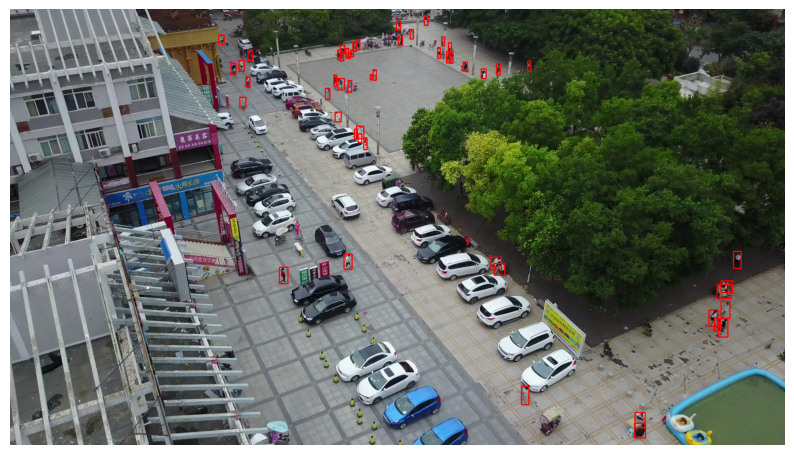

In [32]:
rootdir = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/images/'
gt_filepath = "/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/annotations_VisDroneHumans_val.json"
with open(gt_filepath, 'r') as f:
    gt_anns = json.load(f)
    f.close()

gt_anns = gt_anns["annotations"]
plot_annotations(rootdir, gt_anns, 8, (1,2))

In [79]:
for ann in gt_anns:
    if ann["image_id"] == 8:
        print(ann)

{'id': 221, 'image_id': 8, 'category_id': 0, 'bbox': [495, 2, 83, 58], 'area': 4814, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 222, 'image_id': 8, 'category_id': 1, 'bbox': [517, 64, 13, 23], 'area': 299, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 223, 'image_id': 8, 'category_id': 0, 'bbox': [915, 49, 49, 48], 'area': 2352, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 224, 'image_id': 8, 'category_id': 0, 'bbox': [945, 2, 124, 21], 'area': 2604, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 225, 'image_id': 8, 'category_id': 0, 'bbox': [868, 73, 50, 32], 'area': 1600, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 226, 'image_id': 8, 'category_id': 1, 'bbox': [1026, 16, 9, 24], 'area': 216, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 227, 'image_id': 8, 'category_id': 1, 'bbox': [957, 30, 10, 22], 'area': 220, 'iscrowd': 0, 'ignore': 0, 'segmentation': []}
{'id': 228, 'image_id': 8, 'category_id': 1, 'bbox': [991, 50, 8, 24], 'a

In [ ]:

# Process the model output to get object proposals
proposals = process_outputs(outputs, input_vstream_info.shape[:-1], bbox_conf_thresh)

# Apply non-max suppression to filter overlapping proposals
proposal_indices = nms_sorted_boxes(calc_iou(proposals[:, :-2]), iou_thresh)
proposals = proposals[proposal_indices]

# Extract bounding boxes, labels, and probabilities from proposals
bbox_list = [adjust_bbox(bbox, transform_data) for bbox in proposals[:,:4]]
label_list = [class_names[int(idx)] for idx in proposals[:,4]]
probs_list = proposals[:,5]

# Initialize track IDs for detected objects
track_ids = [-1]*len(bbox_list)

# Convert bounding boxes to top-left bottom-right (tlbr) format
tlbr_boxes = np.array(bbox_list).reshape(-1,4).copy()
tlbr_boxes[:, 2:4] += tlbr_boxes[:, :2]

# Update tracker with detections
tracks = tracker.update(
    output_results=np.concatenate([tlbr_boxes, probs_list[:, np.newaxis]], axis=1),
    img_info=frame.shape[::-1][1:],
    img_size=frame.shape[::-1][1:])

if len(tlbr_boxes) > 0 and len(tracks) > 0:
    # Match detections with tracks
    track_ids = match_detections_with_tracks(tlbr_boxes=tlbr_boxes, track_ids=track_ids, tracks=tracks)

    # Filter object detections based on tracking results
    bbox_list, label_list, probs_list, track_ids = zip(*[(bbox, label, prob, track_id) 
                                                        for bbox, label, prob, track_id 
                                                        in zip(bbox_list, label_list, probs_list, track_ids) if track_id != -1])
    
    if len(bbox_list) > 0:
        # Annotate the current frame with bounding boxes and tracking IDs
        annotated_img = draw_bboxes_pil(
            image=Image.fromarray(frame), 
            boxes=bbox_list, 
            labels=[f"{track_id}-{label}" for track_id, label in zip(track_ids, label_list)],
            probs=probs_list,
            colors=[int_colors[class_names.index(i)] for i in label_list],  
            font=font_file,
        )
        annotated_frame = cv2.resize(np.array(annotated_img), (preview_width, preview_height))
else:
    # If no detections, use the original frame
    annotated_frame = cv2.resize(frame, (preview_width, preview_height))

# Calculate and display FPS
end_time = time.perf_counter()
processing_time = end_time - start_time
fps = 1 / processing_time

fps_text = f"FPS: {fps:.2f}"
cv2.putText(annotated_frame, fps_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Display the annotated frame
cv2.imshow(window_title, annotated_frame)

# Check for 'q' key press to exit the loop
if cv2.waitKey(1) & 0xFF == ord('q'):
    break
finally:
    # Stop the camera and close the preview window
    cv2.destroyAllWindows()
    picam2.close()